# Emotional-Intensity Mismatch in Speaker-Independent SER

This is the **core experiment** of the project. It directly trains and evaluates an RBF-SVM under six emotional-intensity conditions:

- Normal to Normal
- Normal to Strong
- Strong to Strong
- Strong to Normal
- Mixed to Normal
- Mixed to Strong

The public feature table contains 576 RAVDESS speech recordings from 24 actors, restricted to Happy, Sad, and Angry. It contains 31 acoustic features plus actor, emotion, and intensity labels. Raw audio and private file paths are not included.

[Read the full project report](../report/SER_Project_Report.pdf)


## Reproducibility note

This notebook reruns the six conditions from the public derived feature table. Every fold keeps test actors completely outside the training data. Median imputation and standardization are fitted only on the training portion of each fold.

The split is fixed with `StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)` so the public rerun is deterministic. The repository's archived result CSV and report remain the record of the original experimental run.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)


## 1. Load and validate the sanitized feature table


In [2]:
candidate_paths = [
    Path("../data/ravdess_intensity_features.csv"),
    Path("data/ravdess_intensity_features.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Place ravdess_intensity_features.csv in the repository's data/ folder."
    )

data = pd.read_csv(data_path).reset_index(drop=True)
feature_columns = [
    "duration", "energy_mean", "energy_std", "pitch_mean", "pitch_std",
] + [
    f"mfcc_{i}_{stat}"
    for i in range(1, 14)
    for stat in ("mean", "std")
]

required_columns = {"actor_id", "emotion", "intensity", *feature_columns}
assert required_columns.issubset(data.columns)
assert len(feature_columns) == 31
assert len(data) == 576
assert data["actor_id"].nunique() == 24
assert set(data["emotion"]) == {"Happy", "Sad", "Angry"}
assert set(data["intensity"]) == {"Normal", "Strong"}

print(f"Rows: {len(data)}")
print(f"Actors: {data['actor_id'].nunique()}")
print(f"Acoustic features: {len(feature_columns)}")
display(pd.crosstab(data["emotion"], data["intensity"]))


Rows: 576
Actors: 24
Acoustic features: 31


intensity,Normal,Strong
emotion,,
Angry,96,96
Happy,96,96
Sad,96,96


## 2. Define feature groups and experimental conditions


In [3]:
feature_groups = {
    "Pitch": ["pitch_mean", "pitch_std"],
    "Prosody": [
        "duration", "energy_mean", "energy_std", "pitch_mean", "pitch_std"
    ],
    "MFCC": [
        f"mfcc_{i}_{stat}"
        for i in range(1, 14)
        for stat in ("mean", "std")
    ],
    "Fusion": feature_columns,
}

conditions = {
    "Normal_to_Normal": (["Normal"], "Normal"),
    "Normal_to_Strong": (["Normal"], "Strong"),
    "Strong_to_Strong": (["Strong"], "Strong"),
    "Strong_to_Normal": (["Strong"], "Normal"),
    "Mixed_to_Normal": (["Normal", "Strong"], "Normal"),
    "Mixed_to_Strong": (["Normal", "Strong"], "Strong"),
}

emotion_order = ["Happy", "Sad", "Angry"]
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(splitter.split(data, data["emotion"], groups=data["actor_id"]))

for fold_number, (train_index, test_index) in enumerate(folds, start=1):
    train_actors = set(data.iloc[train_index]["actor_id"])
    test_actors = set(data.iloc[test_index]["actor_id"])
    assert train_actors.isdisjoint(test_actors)
    print(
        f"Fold {fold_number}: {len(train_actors)} training actors, "
        f"{len(test_actors)} test actors"
    )


Fold 1: 19 training actors, 5 test actors
Fold 2: 19 training actors, 5 test actors
Fold 3: 19 training actors, 5 test actors
Fold 4: 19 training actors, 5 test actors
Fold 5: 20 training actors, 4 test actors


## 3. Train and evaluate one condition


In [4]:
def evaluate_condition(train_intensities, test_intensity, features):
    all_true = []
    all_predicted = []

    for train_index, test_index in folds:
        train_fold = data.iloc[train_index]
        test_fold = data.iloc[test_index]

        train_fold = train_fold[
            train_fold["intensity"].isin(train_intensities)
        ]
        test_fold = test_fold[
            test_fold["intensity"].eq(test_intensity)
        ]

        pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "classifier",
                    SVC(
                        kernel="rbf",
                        C=1.0,
                        gamma="scale",
                        class_weight="balanced",
                    ),
                ),
            ]
        )
        pipeline.fit(train_fold[features], train_fold["emotion"])
        predicted = pipeline.predict(test_fold[features])

        all_true.extend(test_fold["emotion"].tolist())
        all_predicted.extend(predicted.tolist())

    accuracy = accuracy_score(all_true, all_predicted)
    macro_f1 = f1_score(all_true, all_predicted, average="macro")
    recalls = recall_score(
        all_true,
        all_predicted,
        labels=emotion_order,
        average=None,
        zero_division=0,
    )
    matrix = confusion_matrix(all_true, all_predicted, labels=emotion_order)

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "recalls": dict(zip(emotion_order, recalls)),
        "confusion_matrix": matrix,
        "n_predictions": len(all_true),
    }


## 4. Run all feature groups and all six intensity conditions


In [5]:
rows = []
evaluation_details = {}

for feature_group, features in feature_groups.items():
    for condition, (train_intensities, test_intensity) in conditions.items():
        result = evaluate_condition(train_intensities, test_intensity, features)
        evaluation_details[(feature_group, condition)] = result
        rows.append(
            {
                "Feature_Group": feature_group,
                "Condition": condition,
                "Accuracy_%": 100 * result["accuracy"],
                "Macro_F1_%": 100 * result["macro_f1"],
                "Happy_Recall_%": 100 * result["recalls"]["Happy"],
                "Sad_Recall_%": 100 * result["recalls"]["Sad"],
                "Angry_Recall_%": 100 * result["recalls"]["Angry"],
                "Predictions": result["n_predictions"],
            }
        )

results = pd.DataFrame(rows)
macro_f1_table = results.pivot(
    index="Condition", columns="Feature_Group", values="Macro_F1_%"
).loc[list(conditions)]

print("Macro F1 (%)")
display(macro_f1_table.round(2))


Macro F1 (%)


Feature_Group,Fusion,MFCC,Pitch,Prosody
Condition,,,,
Normal_to_Normal,76.66,75.99,42.48,66.80
Normal_to_Strong,46.79,50.60,41.35,42.94
Strong_to_Strong,83.93,82.14,48.67,75.70
Strong_to_Normal,39.96,41.50,40.36,30.17
Mixed_to_Normal,71.77,72.07,42.40,46.72
Mixed_to_Strong,74.17,71.38,50.01,72.49


## 5. Core Fusion results


In [6]:
fusion_results = (
    results[results["Feature_Group"].eq("Fusion")]
    .set_index("Condition")
    .loc[list(conditions)]
    .reset_index()
)
display(fusion_results.round(2))

scores = fusion_results.set_index("Condition")["Macro_F1_%"]
matched_mean = scores[["Normal_to_Normal", "Strong_to_Strong"]].mean()
mismatched_mean = scores[["Normal_to_Strong", "Strong_to_Normal"]].mean()
mixed_mean = scores[["Mixed_to_Normal", "Mixed_to_Strong"]].mean()

print(f"Matched-condition mean Macro F1: {matched_mean:.2f}%")
print(f"Mismatched-condition mean Macro F1: {mismatched_mean:.2f}%")
print(f"Mixed-training mean Macro F1: {mixed_mean:.2f}%")
print(f"Mismatch loss: {matched_mean - mismatched_mean:.2f} percentage points")


Matched-condition mean Macro F1: 80.29%
Mismatched-condition mean Macro F1: 43.37%
Mixed-training mean Macro F1: 72.97%
Mismatch loss: 36.92 percentage points


,Condition,Feature_Group,Accuracy_%,Macro_F1_%,Happy_Recall_%,Sad_Recall_%,Angry_Recall_%,Predictions
0,Normal_to_Normal,Fusion,76.74,76.66,68.75,83.33,78.12,288
1,Normal_to_Strong,Fusion,50.69,46.79,22.92,32.29,96.88,288
2,Strong_to_Strong,Fusion,83.68,83.93,84.38,78.12,88.54,288
3,Strong_to_Normal,Fusion,48.61,39.96,40.62,98.96,6.25,288
4,Mixed_to_Normal,Fusion,72.22,71.77,64.58,90.62,61.46,288
5,Mixed_to_Strong,Fusion,74.65,74.17,64.58,64.58,94.79,288


## 6. Visual comparison


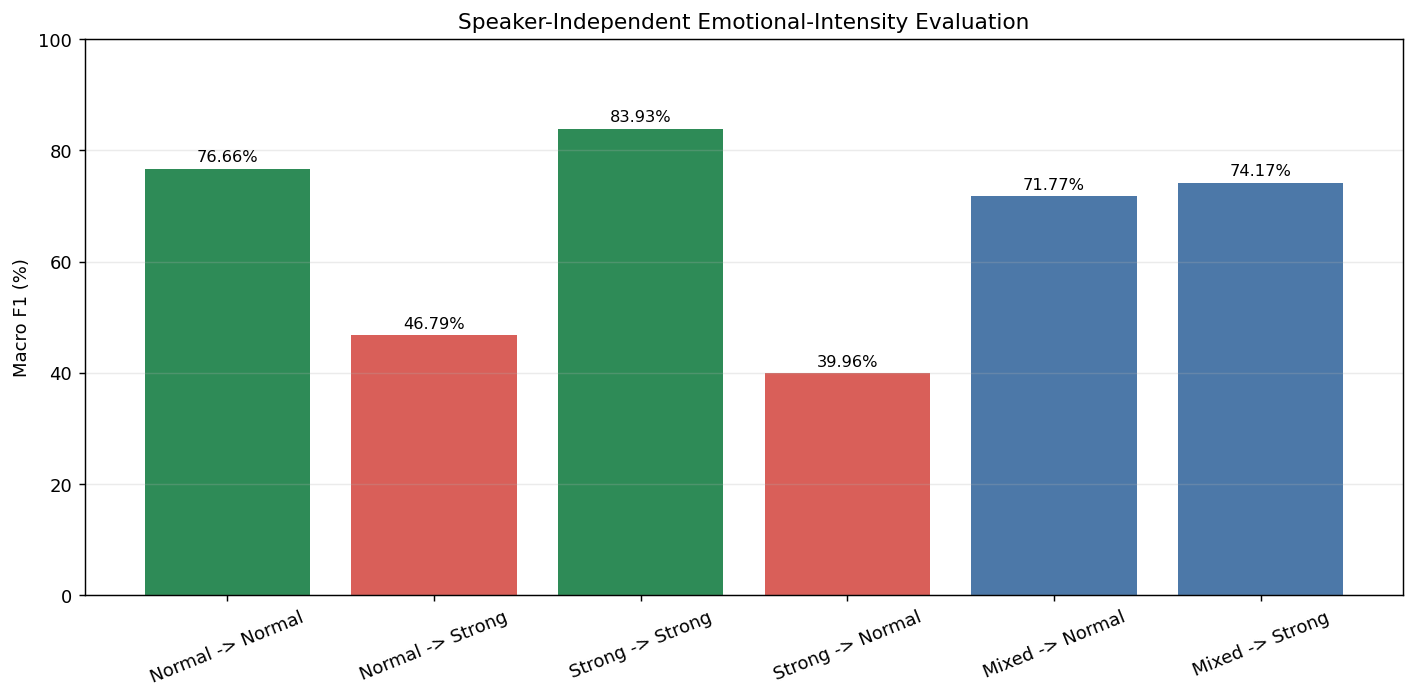

In [7]:
label_map = {
    "Normal_to_Normal": "Normal -> Normal",
    "Normal_to_Strong": "Normal -> Strong",
    "Strong_to_Strong": "Strong -> Strong",
    "Strong_to_Normal": "Strong -> Normal",
    "Mixed_to_Normal": "Mixed -> Normal",
    "Mixed_to_Strong": "Mixed -> Strong",
}
color_map = {
    "Normal_to_Normal": "#2E8B57",
    "Strong_to_Strong": "#2E8B57",
    "Normal_to_Strong": "#D95F59",
    "Strong_to_Normal": "#D95F59",
    "Mixed_to_Normal": "#4C78A8",
    "Mixed_to_Strong": "#4C78A8",
}

plot_data = fusion_results.copy()
plot_data["Label"] = plot_data["Condition"].map(label_map)
colors = plot_data["Condition"].map(color_map)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(plot_data["Label"], plot_data["Macro_F1_%"], color=colors)
ax.set_ylim(0, 100)
ax.set_ylabel("Macro F1 (%)")
ax.set_title("Speaker-Independent Emotional-Intensity Evaluation")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=22)
for bar, value in zip(bars, plot_data["Macro_F1_%"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.3,
        f"{value:.2f}%",
        ha="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()


## 7. Directional confusion matrices


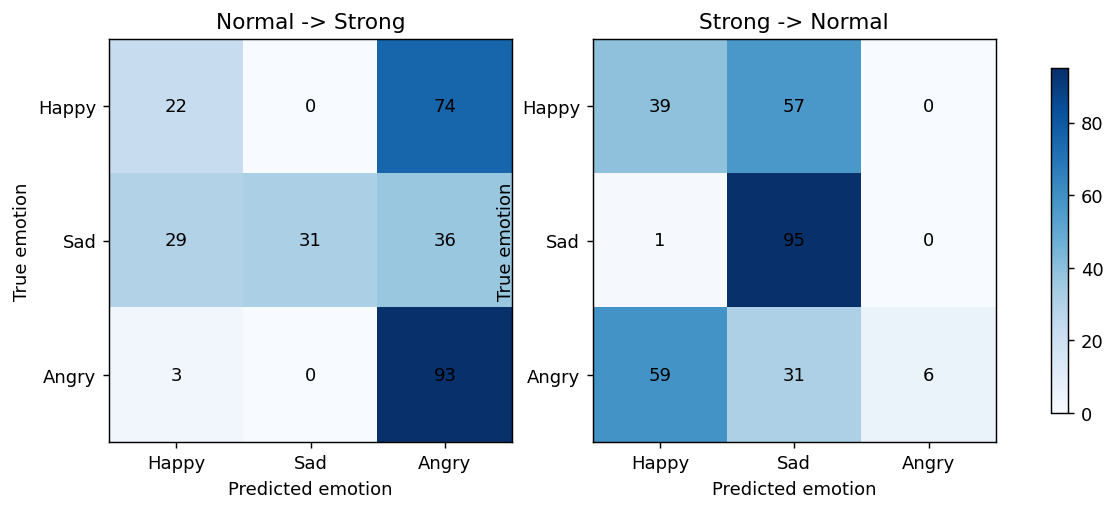

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, condition in zip(axes, ["Normal_to_Strong", "Strong_to_Normal"]):
    matrix = evaluation_details[("Fusion", condition)]["confusion_matrix"]
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(label_map[condition])
    ax.set_xticks(range(len(emotion_order)), emotion_order)
    ax.set_yticks(range(len(emotion_order)), emotion_order)
    ax.set_xlabel("Predicted emotion")
    ax.set_ylabel("True emotion")
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(column, row, matrix[row, column], ha="center", va="center")
fig.colorbar(image, ax=axes, shrink=0.82)
plt.show()


## Interpretation

The six-condition design tests a distribution-mismatch question rather than only a standard emotion-classification benchmark. If matched-intensity scores are substantially higher than mismatched scores, the model is relying partly on intensity-dependent acoustic patterns. The two mismatch directions can also fail differently, which is visible in the confusion matrices.

Mixed-intensity training exposes the classifier to a broader acoustic distribution. When its performance is higher than the mismatched conditions, it provides a practical robustness strategy: include multiple expression intensities in training data.

These findings apply to this RAVDESS, handcrafted-feature, RBF-SVM setup. They do not establish that a model can infer a person's true internal emotional state, and they should not automatically be generalized to spontaneous speech or every language.
